
He_R1s(r) =
+4.7533 * exp(-1.4595 r)
-0.2369 * r^2 * exp(-5.3244 r)
-1.3016 * r * exp(-2.6298 r)
-1.2674 * r * exp(-1.7504 r)
Norm 1s = 1.0000016332731243
                Q  J_1s_one_electron      J_1s(2)  J_total_helium
0    0.000000e+00       5.349431e-01 1.069886e+00    1.069886e+00
1    5.000000e-02       5.332244e-01 1.066449e+00    1.066449e+00
2    1.000000e-01       5.281151e-01 1.056230e+00    1.056230e+00
3    1.500000e-01       5.197529e-01 1.039506e+00    1.039506e+00
4    2.000000e-01       5.083585e-01 1.016717e+00    1.016717e+00
...           ...                ...          ...             ...
1996 9.980000e+01       2.113469e-11 4.226939e-11    4.226939e-11
1997 9.985000e+01       2.107657e-11 4.215314e-11    4.215314e-11
1998 9.990000e+01       2.101865e-11 4.203731e-11    4.203731e-11
1999 9.995000e+01       2.096094e-11 4.192188e-11    4.192188e-11
2000 1.000000e+02       2.090342e-11 4.180685e-11    4.180685e-11

[2001 rows x 4 columns]

Saved: Helium_HF1_Compton_

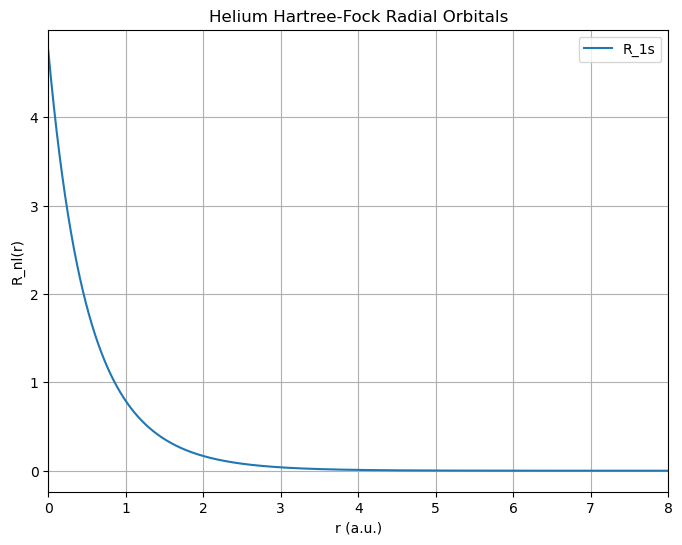

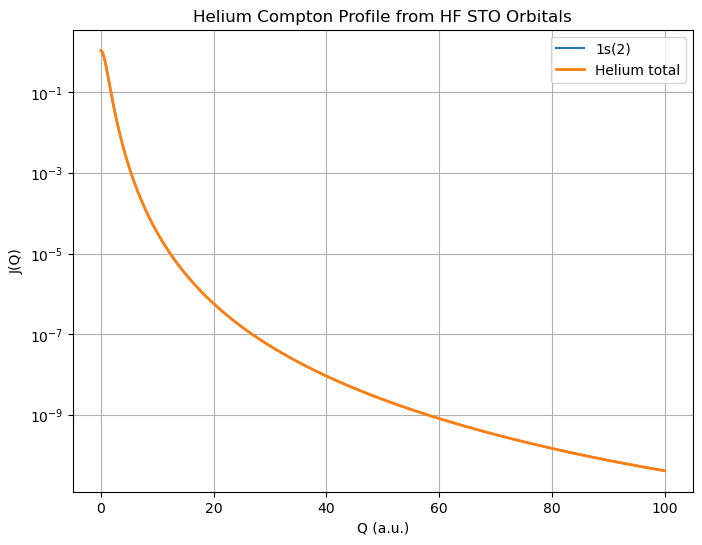

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Helium Hartree-Fock STO data from your table
# r and p are in atomic units
# =====================================================
# Format: (n_j, Z_j, C_j)
helium_1s = [
    (1, 1.4595,  1.347900),
    (3, 5.3244, -0.001613),
    (2, 2.6298, -0.100506),
    (2, 1.7504, -0.270779),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================
r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 2000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid
# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================
def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)
# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================
def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]
# Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )
    J_p = -0.5 * rev_integral[::-1]

# Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)
    return I, J_Q

# =====================================================
# Build Helium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        
R1s = R_nl(r, helium_1s)

print_R_formula(helium_1s, "He_R1s")

# =====================================================
# Momentum-space wavefunctions
# =====================================================
chi_1s = chi_p(p, r, R1s, l=0)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
# Helium has 1s2 
J_total = 2*J_1s 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_1s(2)": 2*J_1s,
    "J_total_helium": J_total
})
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6e}".format)
print(table)
table.to_csv("Helium_HF_Compton_profile.csv", index=False)
print("\nSaved: Helium_HF1_Compton_profile.csv")

# =====================================================
# Plot radial orbitals
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Helium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, J_total, label="Helium total", linewidth=2)
plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Helium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()